## **Сеть с остаточными связями (ResNet)**



**Идея остаточного обучения**

Разработчики Microsoft Research (Kaiming He, Xiangyu Zhang, Shaoqing Ren, Jian Sun, 2015) предложили ключевую идею:
вместо того чтобы каждый слой пытался выучить новое сложное отображение
𝐻(𝑥), пусть он учится лишь остатку между желаемым выходом и входом:

𝐹(𝑥)=𝐻(𝑥)−𝑥

тогда итоговое преобразование выражается как:

𝐻(𝑥)=𝐹(𝑥)+𝑥

Здесь
𝑥 — это **skip connection** (прямая связь, минующая несколько слоёв).
Такой приём оказался удивительно эффективным — сеть запоминает, как выглядело исходное представление, и просто корректирует его.


Без skip connection: каждый слой должен выучить новое, возможно, сильно нелинейное преобразование 𝐻(𝑥).

С skip connection: слой учится только "исправлению ошибки" — тому, что нужно добавить к входу.
Это гораздо проще оптимизировать, ведь если оптимум уже найден, блок может просто вернуть ноль:

𝐹(𝑥)=0⇒𝐻(𝑥)=𝑥

То есть блок просто пропускает информацию без искажений.




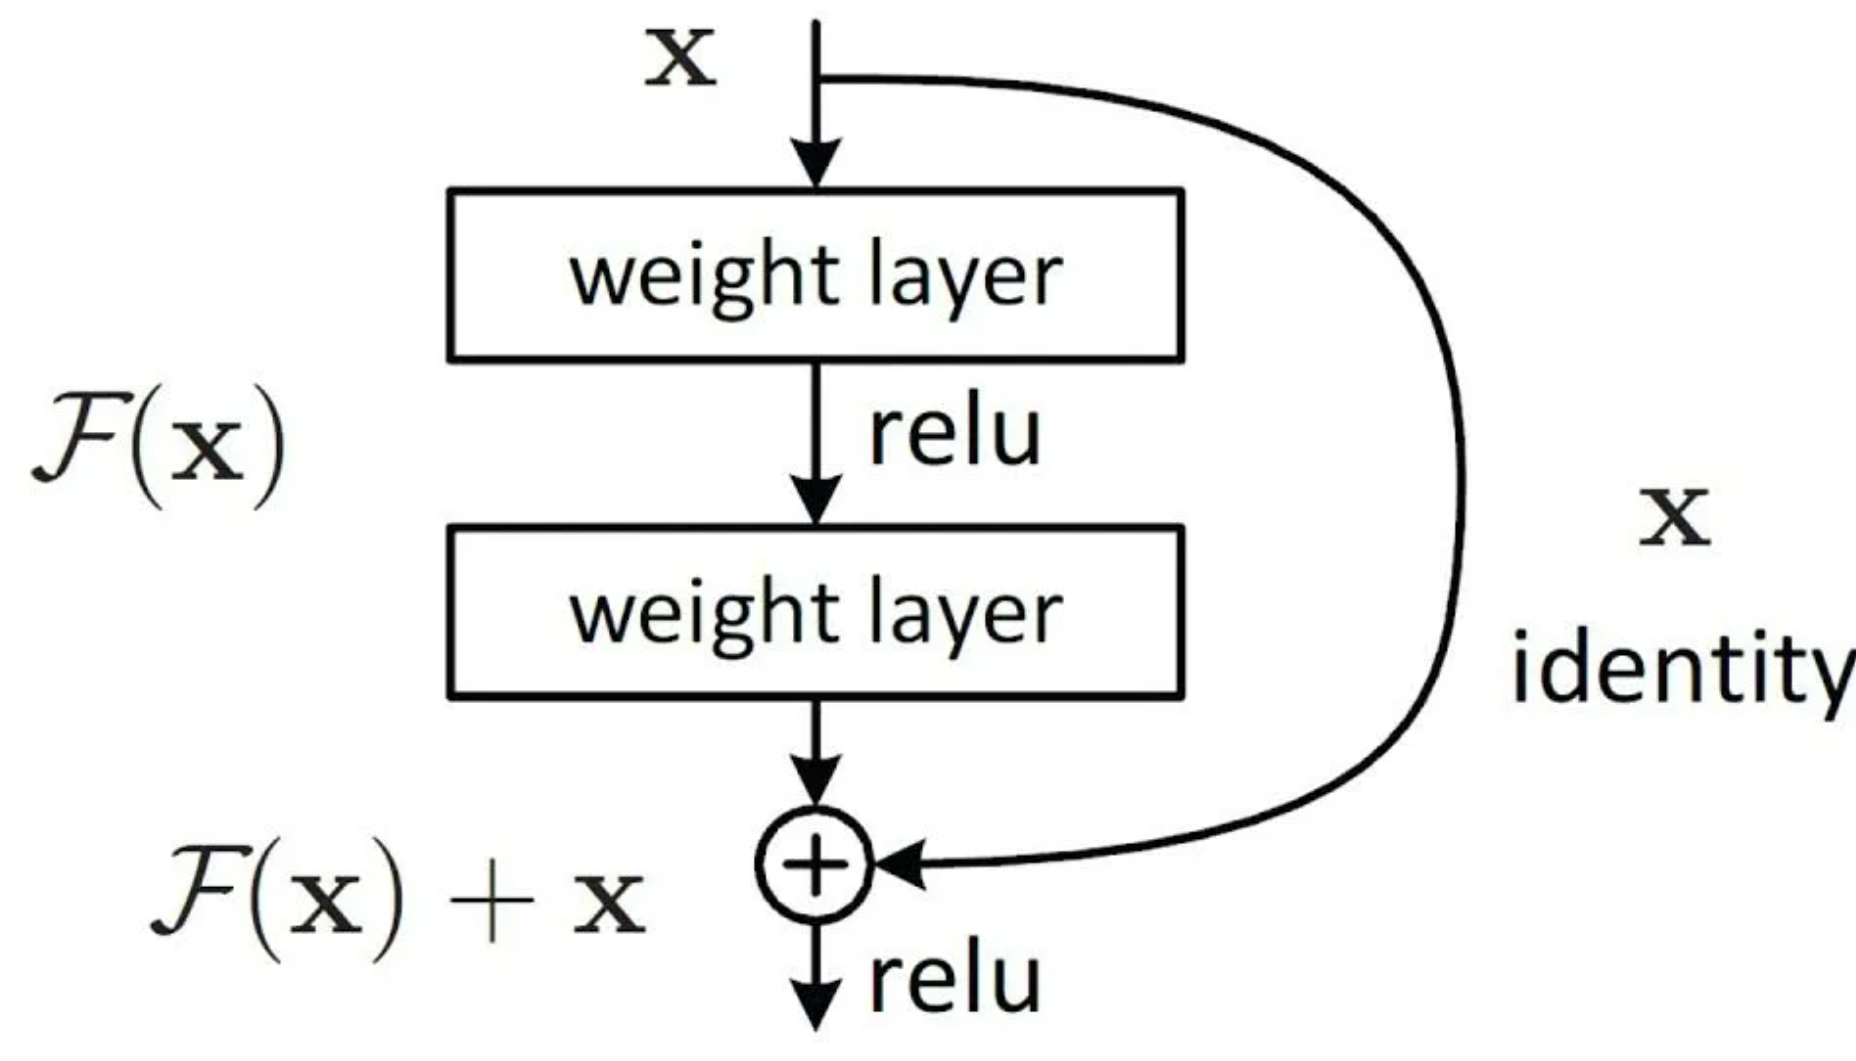

## Пошаговая реализация ResNet18

Ключевые компоненты ResNet:

*  Residual Block — основной строительный блок с skip connections
*  Skip connections — прямые соединения, которые “перепрыгивают” через слои
*  Batch Normalization — нормализация для стабилизации обучения
*  ReLU активация — стандартная функция активации


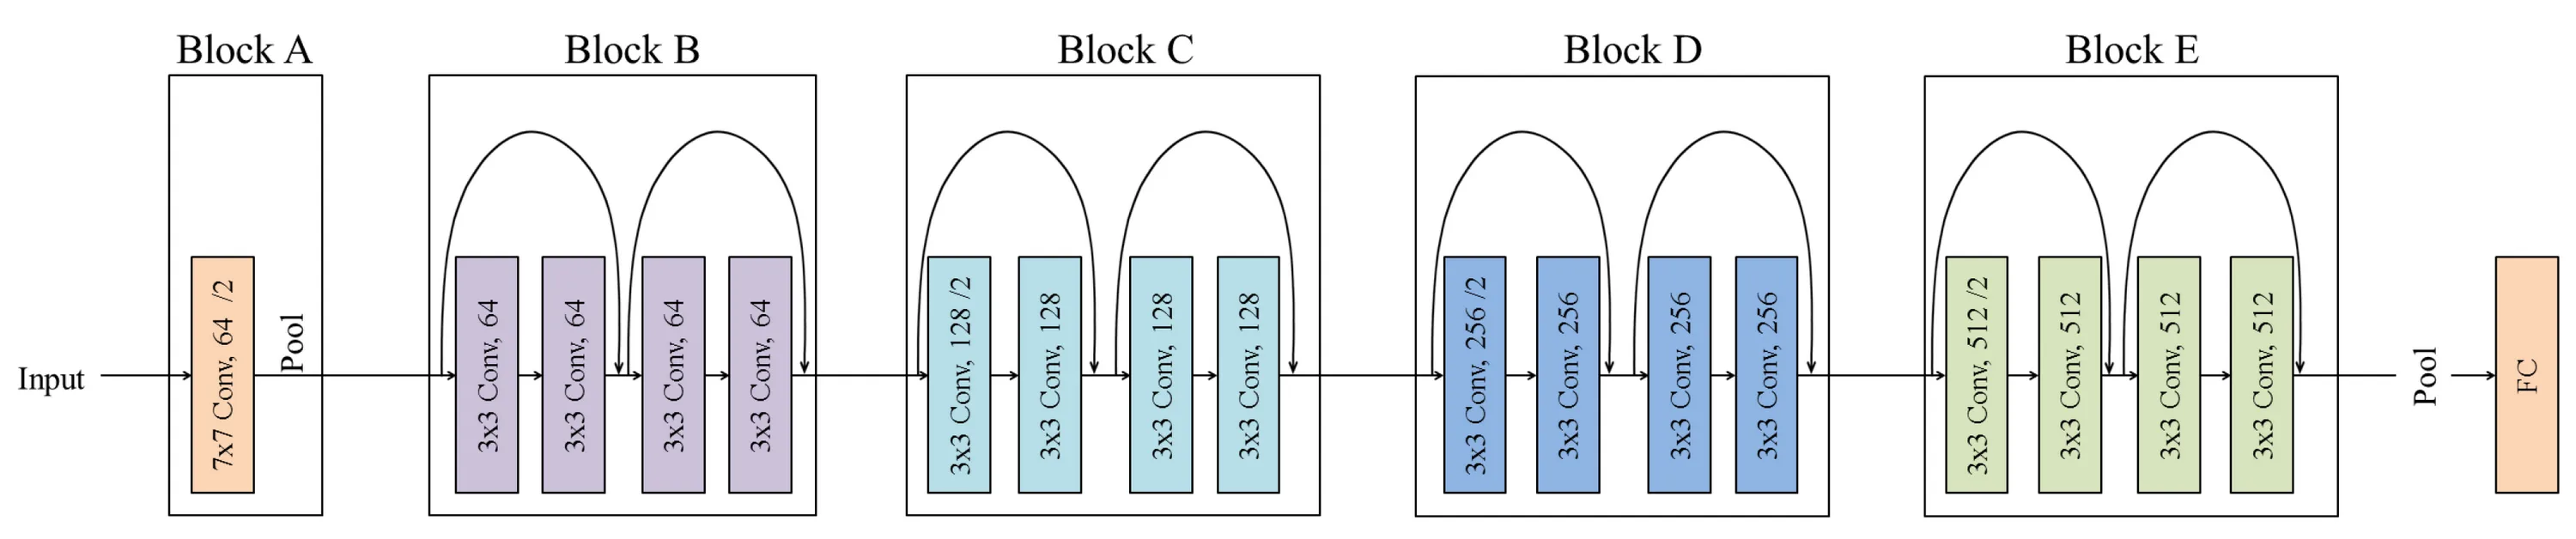

Модель состоит из:
*  Начального свёрточного слоя (обработка входного изображения)
*  Четырёх последовательных блоков (block B - block E), каждый из которых уменьшает размер карты признаков и увеличивает число каналов
*  Среднего pooling-а
*  Финального полносвязного слоя для классификации

In [ ]:
from torchvision import models

model = models.resnet18()
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

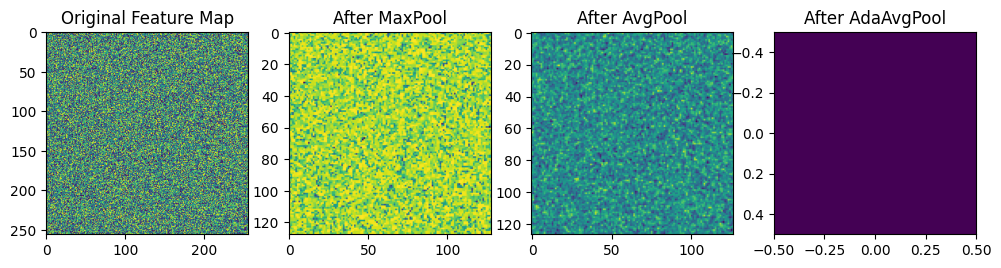

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


feature_map = torch.rand(1, 1, 256, 256) * 10


max_pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1)
avg_pool = nn.AvgPool2d(kernel_size=3, stride=2)
ada_avg_pool = nn.AdaptiveAvgPool2d((1, 1))


max_pooled = max_pool(feature_map)
avg_pooled = avg_pool(feature_map)
ada_avg_pooled = ada_avg_pool(feature_map)


plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.title("Original Feature Map")
plt.imshow(feature_map[0, 0].detach().numpy(), cmap='viridis')


plt.subplot(1, 4, 2)
plt.title("After MaxPool")
plt.imshow(max_pooled[0, 0].detach().numpy(), cmap='viridis')


plt.subplot(1, 4, 3)
plt.title("After AvgPool")
plt.imshow(avg_pooled[0, 0].detach().numpy(), cmap='viridis')


plt.subplot(1, 4, 4)
plt.title("After AdaAvgPool")
plt.imshow(ada_avg_pooled[0, 0].detach().numpy(), cmap='viridis')

plt.show()


## 1. Класс BasicBlock

Это строительный элемент сети — остаточный блок (residual block).
Он учится не полному преобразованию
𝐻(𝑥), а только разности 𝐹(𝑥)=𝐻(𝑥)−𝑥.
На выходе мы получаем:
𝐻(𝑥)=𝐹(𝑥)+𝑥
где 𝑥 — shortcut (вход блока).

In [ ]:
import torch.nn as nn

class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
           )

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += self.shortcut(x)
        out = self.relu(out)
        return out

## 2. Класс ResNet18

In [ ]:
class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet18, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(BasicBlock, 64, 2, stride=1)
        self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)


    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.maxpool(out)

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

In [ ]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Подготовка данных
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

## Реализация цикла обучения



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet18().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

num_epochs = 10

train_losses = []
val_losses = []
val_accuracies = []

model

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

In [ ]:
for epoch in range(num_epochs):
    # === TRAIN ===
    model.train()
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(trainloader)
    train_losses.append(train_loss)


    # === VALIDATION ===
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(testloader)
    val_losses.append(val_loss)

    accuracy = 100 * correct / total
    val_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss = {train_loss:.4f}, "
          f"Val Loss = {val_loss:.4f}, "
          f"Accuracy = {accuracy:.2f}%")

Epoch 1/10: Train Loss = 1.6041, Val Loss = 1.3220, Accuracy = 52.12%
Epoch 2/10: Train Loss = 1.2271, Val Loss = 1.0601, Accuracy = 61.72%
Epoch 3/10: Train Loss = 1.0625, Val Loss = 0.9840, Accuracy = 65.25%
Epoch 4/10: Train Loss = 0.9561, Val Loss = 0.9061, Accuracy = 68.23%
Epoch 5/10: Train Loss = 0.8681, Val Loss = 0.8554, Accuracy = 69.99%
Epoch 6/10: Train Loss = 0.8027, Val Loss = 0.8104, Accuracy = 72.12%
Epoch 7/10: Train Loss = 0.7524, Val Loss = 0.7816, Accuracy = 72.71%
Epoch 8/10: Train Loss = 0.7078, Val Loss = 0.7236, Accuracy = 74.43%
Epoch 9/10: Train Loss = 0.6729, Val Loss = 0.6684, Accuracy = 77.21%
Epoch 10/10: Train Loss = 0.6398, Val Loss = 0.6471, Accuracy = 77.43%


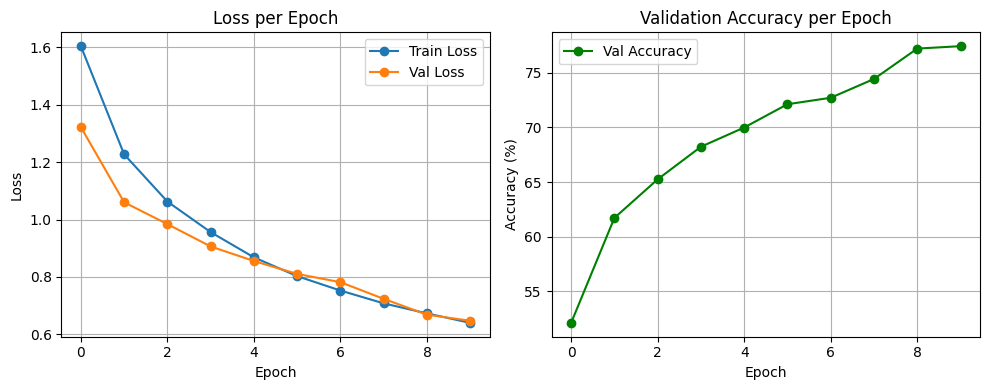

In [ ]:
# === ВИЗУАЛИЗАЦИЯ ===
plt.figure(figsize=(10, 4))

# Loss график
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='o')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')ф
plt.legend()
plt.grid(True)

# Accuracy график
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Val Accuracy', color='green', marker='o')
plt.title('Validation Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Вариации блоков

*  BasicBlock — используется в ResNet-18 и ResNet-34:
состоит из двух сверток
3×3.

*  Bottleneck Block — используется в ResNet-50, 101, 152:
структура:

Блок с узким местом состоит из трёх основных частей:

Сеть в сети (1×1 свёртка) → Свёрточный слой (3×3) → Сеть в сети (1×1 свёртка)



Первая 1×1 свёртка (Network-in-Network, NiN) уменьшает число каналов — это и есть сжатие признаков.
Средний 3×3 слой обучается выделять сложные признаки уже в этом уменьшенном пространстве.
Последняя 1×1 свёртка восстанавливает число каналов до исходного, подготавливая данные для последующих слоёв.

Такой блок используется, например, в Bottleneck-структуре ResNet:

𝑥
→
1
×
1
↓
→
3
×
3
→
1
×
1
↑
→
+
𝑥


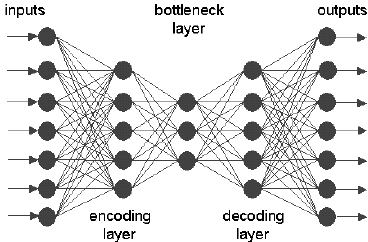

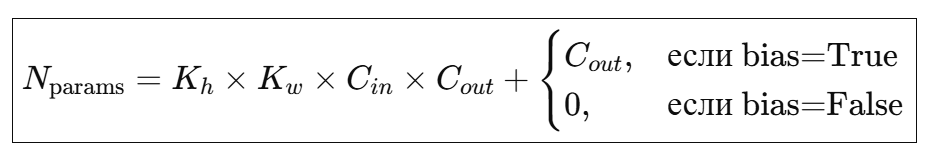

In [ ]:
#пример
import torch
import torch.nn as nn

conv_plain = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=10)

conv_reduce = nn.Conv2d(in_channels=256, out_channels=64, kernel_size=1)
conv_main   = nn.Conv2d(in_channels=64, out_channels=256, kernel_size=10)

def count_params(layer):
    return sum(p.numel() for p in layer.parameters() if p.requires_grad)

plain_params = count_params(conv_plain)
bottleneck_params = count_params(conv_reduce) + count_params(conv_main)


print(f"Количество параметров1: {plain_params:,}")
print(f"Количество параметров2: {bottleneck_params:,}")
ratio = plain_params / bottleneck_params
print(f"\nПараметров меньше примерно в {ratio:.2f} раза.")


Количество параметров1: 6,553,856
Количество параметров2: 1,655,104

Параметров меньше примерно в 3.96 раза.


## Детальнее рассмотрим реализацию Bottleneck в ResNet

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Проверяем доступность GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используем устройство: {device}")

Используем устройство: cuda


In [ ]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)  #skip connection
        out = F.relu(out)
        return out

In [ ]:
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_planes, planes, stride=1):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)

        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.conv3 = nn.Conv2d(planes, self.expansion * planes, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(self.expansion * planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )


    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

In [ ]:
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.linear = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

# Создаём конфигурации
def ResNet18():
    return ResNet(BasicBlock, [2, 2, 2, 2])

def ResNet34():
    return ResNet(BasicBlock, [3, 4, 6, 3])

def ResNet50():
    return ResNet(Bottleneck, [3, 4, 6, 3])

def ResNet101():
    return ResNet(Bottleneck, [3, 4, 23, 3])

def ResNet152():
    return ResNet(Bottleneck, [3, 8, 36, 3])

In [ ]:
num_epochs = 10

net = ResNet18().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

train_losses = []
val_losses = []
val_accuracies = []

In [ ]:
import time

start_time = time.time()  # старт всего обучения

for epoch in range(num_epochs):
    # === TRAIN ===
    net.train()
    running_loss = 0.0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(trainloader)
    train_losses.append(train_loss)

    # === VALIDATION ===
    net.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(testloader)
    val_losses.append(val_loss)
    accuracy = 100 * correct / total
    val_accuracies.append(accuracy)

    scheduler.step()

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss = {train_loss:.4f}, "
          f"Val Loss = {val_loss:.4f}, "
          f"Accuracy = {accuracy:.2f}%")

total_time = time.time() - start_time
print(f"\n Общее время:({total_time:.2f} сек)\n")


Epoch 1/10: Train Loss = 1.6221, Val Loss = 1.4169, Accuracy = 48.44%
Epoch 2/10: Train Loss = 1.2060, Val Loss = 1.0561, Accuracy = 62.09%
Epoch 3/10: Train Loss = 0.9868, Val Loss = 0.9871, Accuracy = 64.97%
Epoch 4/10: Train Loss = 0.8462, Val Loss = 1.0246, Accuracy = 66.02%
Epoch 5/10: Train Loss = 0.7316, Val Loss = 0.7671, Accuracy = 73.05%
Epoch 6/10: Train Loss = 0.6071, Val Loss = 0.6121, Accuracy = 78.77%
Epoch 7/10: Train Loss = 0.5841, Val Loss = 0.6013, Accuracy = 79.20%
Epoch 8/10: Train Loss = 0.5678, Val Loss = 0.5946, Accuracy = 79.16%
Epoch 9/10: Train Loss = 0.5538, Val Loss = 0.5905, Accuracy = 79.53%
Epoch 10/10: Train Loss = 0.5427, Val Loss = 0.5796, Accuracy = 80.01%

 Общее время:(429.19 сек)



# Понимание инициализации весов в нейронных сетях


| Метод               | Особенности                            | Подходит для        |
| ------------------- | -------------------------------------- | ------------------- |
| **Constant (0, 1)** | Все веса одинаковы → нейроны не учатся | Никогда             |
| **Uniform/Normal**  | Случайно, но без учёта архитектуры     | Простые сети        |
| **LeCun**           | Масштабирует по числу входов           | `tanh`, `sigmoid`   |
| **Xavier**          | Балансирует вход/выход                 | универсально        |
| **He (Kaiming)**    | Учитывает ReLU — сохраняет дисперсию   | ResNet, VGG, YOLO |


In [ ]:
#Constant (0, 1)
layer = nn.Linear(64, 32, bias=False)
nn.init.constant_(layer.weight, 1.0)

print(layer.weight[:2, :5])

tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]], grad_fn=<SliceBackward0>)


In [ ]:
#Uniform
layer = nn.Linear(64, 32, bias=False)
nn.init.uniform_(layer.weight, a=-0.05, b=0.05)

print(layer.weight[:2, :5])

tensor([[-0.0319,  0.0379, -0.0303,  0.0424,  0.0177],
        [-0.0025,  0.0347, -0.0452, -0.0375, -0.0159]],
       grad_fn=<SliceBackward0>)


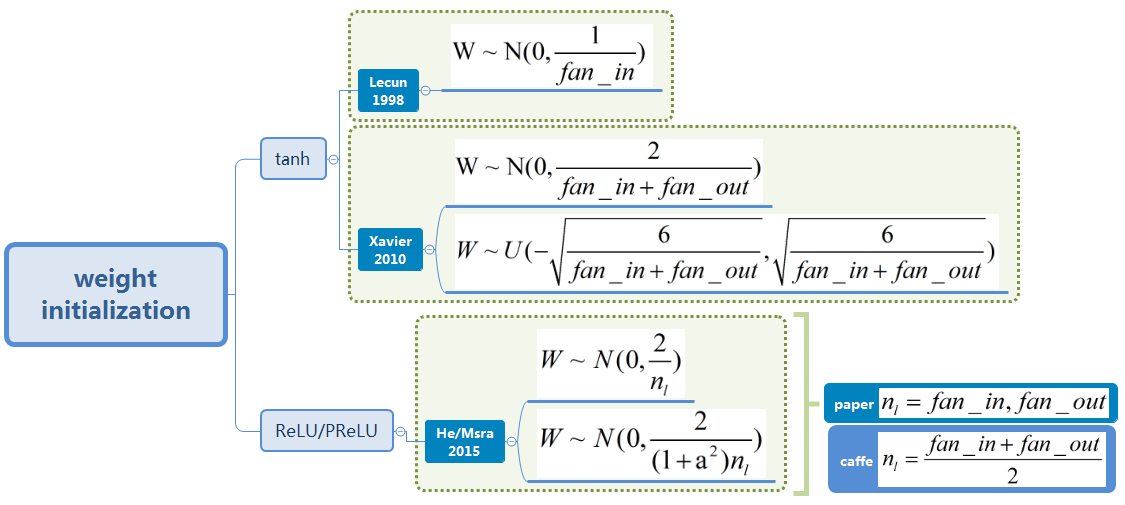

In [ ]:
import math
#LeCun
layer = nn.Linear(64, 32, bias=False)
fan_in, _ = nn.init._calculate_fan_in_and_fan_out(layer.weight)

# LeCun Uniform
limit = math.sqrt(3.0 / fan_in)
nn.init.uniform_(layer.weight, -limit, limit)

# LeCun Normal
# std = math.sqrt(1.0 / fan_in)
# nn.init.normal_(layer.weight, mean=0.0, std=std)


print(layer.weight[:2, :5])

tensor([[ 0.1363, -0.1093, -0.1813,  0.0600,  0.1269],
        [ 0.1818, -0.0111,  0.1315, -0.1950,  0.0339]],
       grad_fn=<SliceBackward0>)


In [ ]:
#Xavier
layer = nn.Linear(64, 32, bias=False)
fan_in, fan_out = nn.init._calculate_fan_in_and_fan_out(layer.weight)

# Xavier Uniform
limit = math.sqrt(6.0 / (fan_in + fan_out))
nn.init.uniform_(layer.weight, -limit, limit)

# Xavier Normal
# std = math.sqrt(2.0 / (fan_in + fan_out))
# nn.init.normal_(layer.weight, mean=0.0, std=std)

print(layer.weight[:2, :5])


tensor([[-0.1881, -0.0860, -0.1198,  0.1525,  0.2341],
        [-0.1672, -0.2400,  0.0469,  0.1634,  0.1860]],
       grad_fn=<SliceBackward0>)


In [ ]:
layer = nn.Linear(128, 64, bias=False)
fan_in, _ = nn.init._calculate_fan_in_and_fan_out(layer.weight)

#He Normal
std = math.sqrt(2.0 / fan_in)
nn.init.normal_(layer.weight, mean=0.0, std=std)

# He Uniform
# limit = math.sqrt(6.0 / fan_in)
# nn.init.uniform_(layer.weight, -limit, limit)

print(layer.weight[:2, :5])


tensor([[-0.2973,  0.0876, -0.2019,  0.2027,  0.1573],
        [-0.1612,  0.1502,  0.0585,  0.0755, -0.2366]],
       grad_fn=<SliceBackward0>)


# Как по умолчанию инициализируются веса в PyTorch




In [ ]:
#nn.Conv2d
conv = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1, bias=True)
print("Форма весов:", conv.weight.shape)
print("Форма bias:", conv.bias.shape)

nn.init.kaiming_uniform_(conv.weight, a=0, mode='fan_in', nonlinearity='relu')
fan_in, _ = nn.init._calculate_fan_in_and_fan_out(conv.weight)
bound = 1 / math.sqrt(fan_in)
nn.init.uniform_(conv.bias, -bound, bound)

print("Среднее значение:", conv.weight.mean().item())
print("Стандартное отклонение:", conv.weight.std().item())
print("Диапазон bias:", (conv.bias.min().item(), conv.bias.max().item()))

Форма весов: torch.Size([16, 3, 3, 3])
Форма bias: torch.Size([16])
Среднее значение: 0.012654507532715797
Стандартное отклонение: 0.2727445662021637
Диапазон bias: (-0.19187049567699432, 0.179810032248497)


In [ ]:
#nn.Linear

linear = nn.Linear(in_features=10, out_features=5, bias=True)

print("Форма weight:", linear.weight.shape)
print("Форма bias:", linear.bias.shape)

nn.init.kaiming_uniform_(linear.weight, a=math.sqrt(5))
fan_in, _ = nn.init._calculate_fan_in_and_fan_out(linear.weight)
bound = 1 / math.sqrt(fan_in)
nn.init.uniform_(linear.bias, -bound, bound)

print("mean:", linear.weight.mean().item())
print("std:", linear.weight.std().item())
print("bias range:", (linear.bias.min().item(), linear.bias.max().item()))

Форма weight: torch.Size([5, 10])
Форма bias: torch.Size([5])
mean: -0.01927047222852707
std: 0.18845410645008087
bias range: (-0.255606085062027, 0.11528754234313965)


Batch Normalization
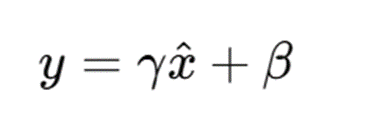

In [ ]:
#BatchNorm2d

bn = nn.BatchNorm2d(num_features=4)
bn.weight.data.fill_(1.0)
bn.bias.data.zero_()
print("gamma (scale):", bn.weight.data)
print("beta (shift):", bn.bias.data)

gamma (scale): tensor([1., 1., 1., 1.])
beta (shift): tensor([0., 0., 0., 0.])


## Ручная переинициализация

In [ ]:
import torch
import torch.nn as nn

def init_weights(m):

    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        print(f"Инициализирован Conv2d слой: {m.__class__.__name__}, форма весов {m.weight.shape}")
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.Linear):

        nn.init.xavier_uniform_(m.weight)
        print(f"Инициализирован Linear слой: {m.__class__.__name__}, форма весов {m.weight.shape}")
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)
        print(f"Инициализирован BatchNorm2d слой: {m.__class__.__name__}")


model = ResNet18()
model.apply(init_weights)


Инициализирован Conv2d слой: Conv2d, форма весов torch.Size([64, 3, 3, 3])
Инициализирован BatchNorm2d слой: BatchNorm2d
Инициализирован Conv2d слой: Conv2d, форма весов torch.Size([64, 64, 3, 3])
Инициализирован BatchNorm2d слой: BatchNorm2d
Инициализирован Conv2d слой: Conv2d, форма весов torch.Size([64, 64, 3, 3])
Инициализирован BatchNorm2d слой: BatchNorm2d
Инициализирован Conv2d слой: Conv2d, форма весов torch.Size([64, 64, 3, 3])
Инициализирован BatchNorm2d слой: BatchNorm2d
Инициализирован Conv2d слой: Conv2d, форма весов torch.Size([64, 64, 3, 3])
Инициализирован BatchNorm2d слой: BatchNorm2d
Инициализирован Conv2d слой: Conv2d, форма весов torch.Size([128, 64, 3, 3])
Инициализирован BatchNorm2d слой: BatchNorm2d
Инициализирован Conv2d слой: Conv2d, форма весов torch.Size([128, 128, 3, 3])
Инициализирован BatchNorm2d слой: BatchNorm2d
Инициализирован Conv2d слой: Conv2d, форма весов torch.Size([128, 64, 1, 1])
Инициализирован BatchNorm2d слой: BatchNorm2d
Инициализирован Conv2

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=

## Смешанная точность (Mixed Precision Training)

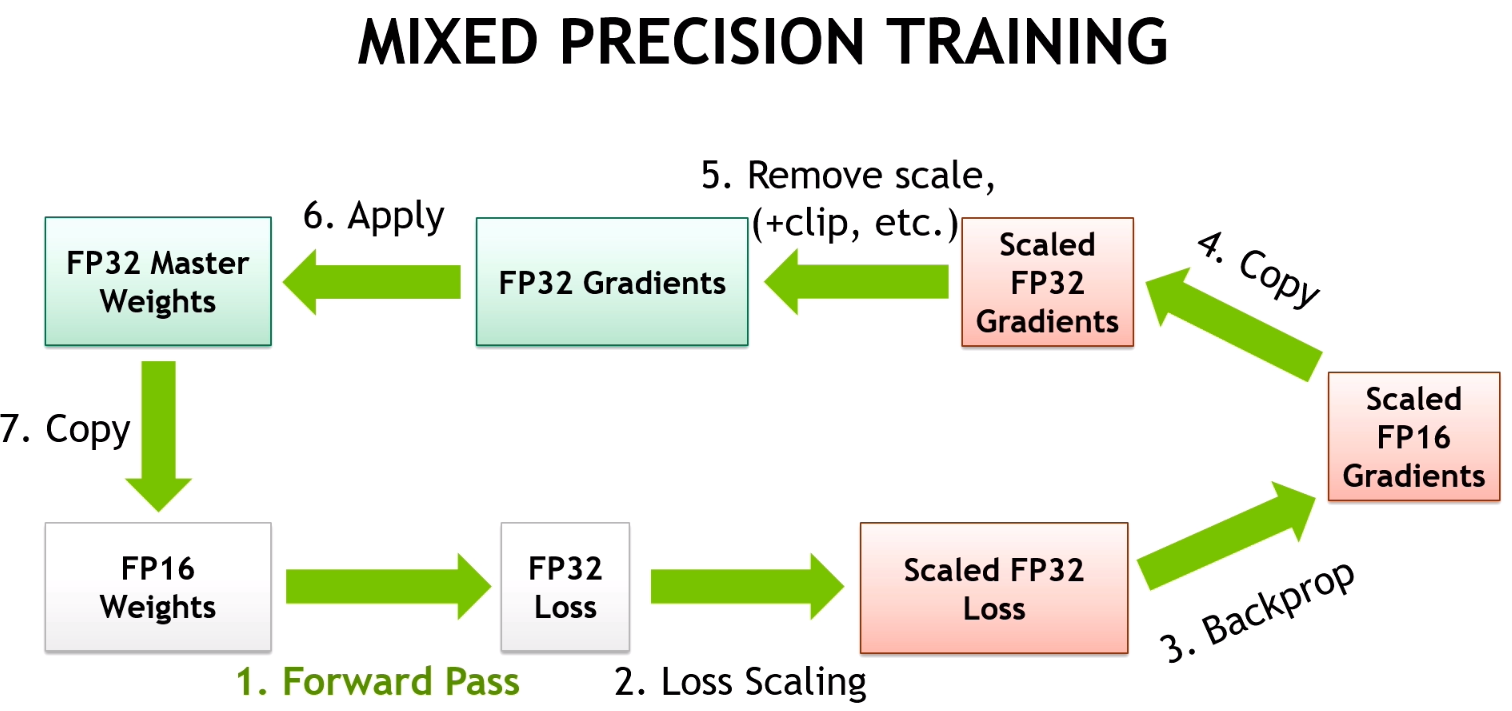

In [ ]:
# Использование смешанной точности для экономии памяти
import time
from torch import amp
from torch.amp import autocast, GradScaler

scaler = GradScaler()

def train_with_mixed_precision(epoch):
    net.train()
    running_loss = 0.0
    correct = 0
    total = 0
    start_time = time.time()

    for batch_idx, (inputs, targets) in enumerate(trainloader):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()

        with autocast(device_type=device.type):  # смешанная точность
            outputs = net(inputs)
            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    end_time = time.time()
    print(f"Epoch {epoch+1}: Loss = {running_loss/len(trainloader):.4f}, "
          f"Accuracy = {100.*correct/total:.2f}%, ")


In [ ]:
# Обучение со смешанной точностью
start = time.time()
for epoch in range(num_epochs):
    train_with_mixed_precision(epoch)
end = time.time()
print(f"\nMixed precision обучение: {end - start:.2f} сек\n")

Epoch 0: Loss = 0.5305, Accuracy = 81.70%, Time = 21.93 sec
Epoch 1: Loss = 0.5255, Accuracy = 81.57%, Time = 21.60 sec
Epoch 2: Loss = 0.5255, Accuracy = 81.67%, Time = 20.83 sec
Epoch 3: Loss = 0.5249, Accuracy = 81.73%, Time = 21.74 sec
Epoch 4: Loss = 0.5238, Accuracy = 81.94%, Time = 21.93 sec
Epoch 5: Loss = 0.5212, Accuracy = 81.73%, Time = 21.25 sec
Epoch 6: Loss = 0.5199, Accuracy = 81.92%, Time = 21.84 sec
Epoch 7: Loss = 0.5197, Accuracy = 81.96%, Time = 22.08 sec
Epoch 8: Loss = 0.5187, Accuracy = 81.91%, Time = 21.91 sec
Epoch 9: Loss = 0.5151, Accuracy = 82.01%, Time = 21.25 sec

Mixed precision обучение: 216.37 сек



## Полезные модификации архитектуры:

### Squeeze-and-Excitation

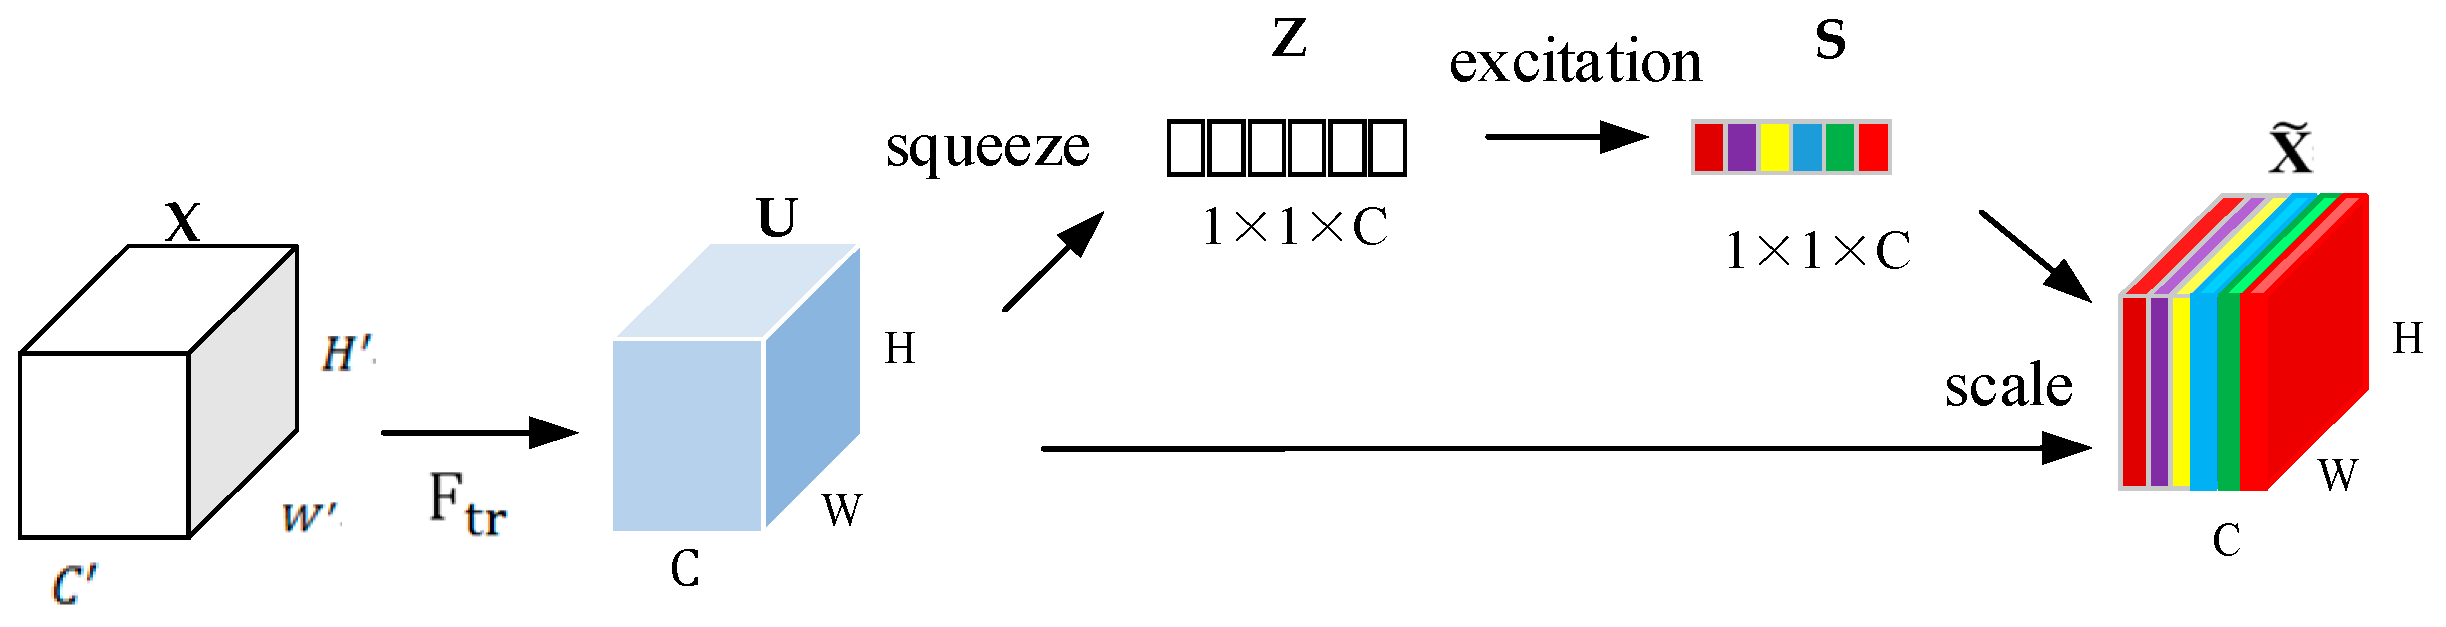

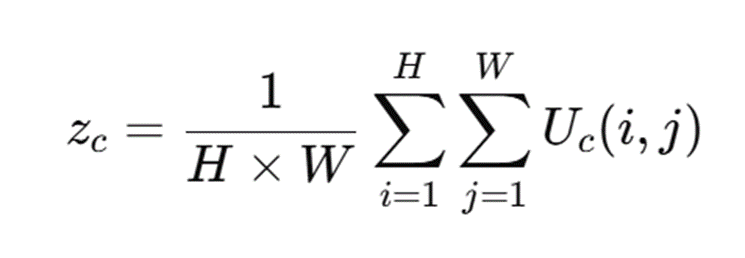

In [ ]:
# ResNet с Squeeze-and-Excitation блоками
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.squeeze(x).view(b, c)
        y = self.excitation(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

# Интеграция в BasicBlock
class SEBasicBlock(BasicBlock):
    def __init__(self, in_planes, planes, stride=1):
        super(SEBasicBlock, self).__init__(in_planes, planes, stride)
        self.se = SEBlock(planes)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)  # Добавляем SE блок
        out += self.shortcut(x)
        out = F.relu(out)
        return out

Интеграция с другими инструментами
Современный ML-пайплайн требует интеграции с множеством инструментов. Вот несколько полезных примеров:

In [ ]:
# Интеграция с TensorBoard
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter('runs/resnet_experiment')

def log_training(epoch, loss, accuracy):
    writer.add_scalar('Loss/Train', loss, epoch)
    writer.add_scalar('Accuracy/Train', accuracy, epoch)

    # Визуализация весов
    for name, param in net.named_parameters():
        writer.add_histogram(name, param, epoch)

# Сохранение и загрузка модели
def save_checkpoint(epoch, model, optimizer, loss):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }, f'checkpoint_epoch_{epoch}.pth')

def load_checkpoint(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    net.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    return epoch, loss

Интеграция с ONNX для деплоя:

In [ ]:
# Экспорт в ONNX
def export_to_onnx():
    net.eval()
    dummy_input = torch.randn(1, 3, 32, 32).to(device)
    torch.onnx.export(net, dummy_input, "resnet.onnx",
                      export_params=True,
                      opset_version=11,
                      do_constant_folding=True,
                      input_names=['input'],
                      output_names=['output'])

## Домашнее задание

| Архитектура                    | Ключевая идея                                                     |  |                                                                      |
| ------------------------------ | ----------------------------------------------------------------- | -------------------- | ------------------------------------------------------------------------------------------ |
| **DenseNet-121 (2017)**    | DКонцепция плотных (dense) связей между слоями (конкатенацию всех feature maps)                      |               |     |
| **MobileNet-V2 (2018)**    | Концепция инвертированных остаточных блоков и разделимых свёрток по глубине (Depthwise Separable Conv)                      |                |                           |
| **ResNeXt-50 (2017)**      | Введение групповых свёрток и концепции split-transform-merge                     |               |                     |
| **GhostNet (2020)**        | Основные feature-map’ы вычисляются обычной свёрткой, а дополнительные (“ghost”) лёгкими линейными преобразованиями


https://forms.gle/e2a8o2ELmZ9693DUA